## correlation matrices

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr
import pandas as pd

In [12]:
stats_orig = [f'SFS_{i}' for i in range(1, 11)] + \
             [f'inter-SNP_{i}' for i in range(1, 37)] + \
             [f'LD_{i}' for i in range(1, 16)] + ['$\pi$', '#haps']

stats_extra = ['ihs_maxabs', "tajimas_d", 'garud_h1', 'garud_h12', 'garud_h123', 'garud_h2_h1']

feature_lst = stats_orig + stats_extra

hidden = np.load('../results/hiddenweights/CEU_3_250626_GBR.npy')
stats = np.load('../data/summary_stats/stats_GBR.npy')

print(hidden.shape, stats.shape)

(277038, 64) (277038, 63)


In [13]:
corrs = np.zeros((hidden.shape[1], stats.shape[1]))
for i in range(hidden.shape[1]):
    for j in range(stats.shape[1]):
        # corrs[i, j] = pearsonr(hidden[:, i], stats[:, j])[0]
        # numpy
        corrs[i, j] = np.corrcoef(hidden[:, i], stats[:, j])[0, 1]

corrs_masked = np.ma.masked_invalid(corrs)

/homes/lzong/envs/env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/homes/lzong/envs/env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [14]:
corrs = corrs_masked.filled(0)
corrs_df = pd.DataFrame(corrs, 
                        columns=stats_orig,
                        index=[f'{i}' for i in range(hidden.shape[1])])

/homes/lzong/envs/env/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


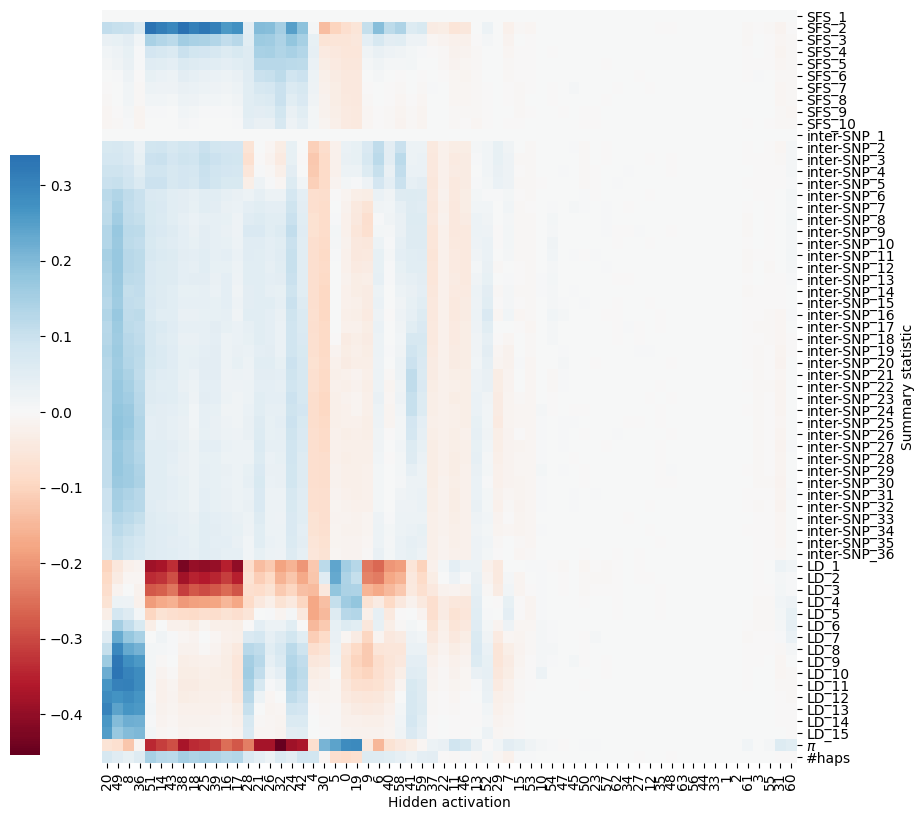

In [15]:
cg = sns.clustermap(corrs_df.T, 
                    cmap='RdBu', 
                    center=0, 
                    square=True, 
                    # cbar_kws={'label': 'Pearson Correlation'},
                    yticklabels=True,
                    xticklabels=True,
                    row_cluster=False)


cg.cax.set_position([0.1, 0.05, .03, 0.6])
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)

cg.ax_heatmap.set_ylabel('Summary statistic')
cg.ax_heatmap.set_xlabel('Hidden activation')

plt.show()

## check prediction distribution

In [23]:
# sanity check
# the predictions are the same?
preds = np.loadtxt('../results/predictions/CEU_3_230410_weights_GBR.txt')[:,-1]
# preds_old = np.loadtxt('../results/predictions/old/prob_CEU_0_230410_GBR.txt')[:,-1]

preds_small = np.loadtxt('../results/predictions/CEU_3_250626_GBR.txt')[:,-1]

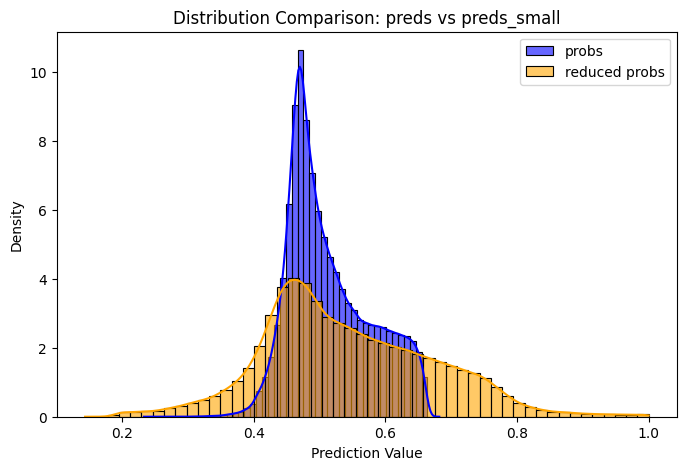

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(preds, bins=50, color='blue', label='probs', stat='density', kde=True, alpha=0.6)
# sns.histplot(preds_old, bins=50, color='green', label='probs (gdrive)', stat='density', kde=True, alpha=0.6)
sns.histplot(preds_small, bins=50, color='orange', label='reduced probs', stat='density', kde=True, alpha=0.6)
plt.legend()
plt.xlabel('Prediction Value')
plt.ylabel('Density')
plt.title('Distribution Comparison: preds vs preds_small')
plt.show()